# Complex I Sequence Extraction

Extract ND gene sequences from:
- `amtdb_seqs/` - Ancient mtDNA Database (2,022 ancient samples)

Uses GFF3 annotations for gene coordinates

In [1]:
import numpy as np
from pathlib import Path
from Bio import SeqIO
from Bio.Seq import Seq

# Load rCRS reference sequence
RCRS_PATH = Path("data/rCRS.fa")
rcrs_record = next(SeqIO.parse(RCRS_PATH, "fasta"))
RCRS_SEQ = str(rcrs_record.seq)
print(f"Loaded rCRS reference: {rcrs_record.id}, length={len(RCRS_SEQ)}")

Loaded rCRS reference: NC_012920.1, length=16569


In [2]:
# Parse GFF3 for Complex I (ND) gene coordinates and extract reference subsequences
def parse_gff3_nd_genes(gff_path, ref_seq):
    """Extract ND gene CDS coordinates from GFF3 and slice reference sequence.
    
    Returns:
        nd_genes: dict of gene metadata (coordinates, strand, lengths, ids)
        nd_ref_seqs: dict of reference subsequences for each gene (coding strand orientation)
    """
    nd_genes = {}
    nd_ref_seqs = {}
    
    with open(gff_path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.strip().split("\t")
            if len(parts) < 9:
                continue
            feature_type = parts[2]
            if feature_type != "CDS":
                continue
            
            seq_id = parts[0]
            source = parts[1]
            
            # Parse attributes
            attrs = dict(item.split("=") for item in parts[8].split(";") if "=" in item)
            gene = attrs.get("gene", "")
            # Only ND genes (Complex I)
            if not gene.startswith("ND"):
                continue
            
            start = int(parts[3])
            end = int(parts[4])
            strand = parts[6]
            phase = parts[7]
            
            # Extract additional identifiers
            protein_id = attrs.get("protein_id", "")
            product = attrs.get("product", "")
            
            # Extract reference subsequence (GFF is 1-based inclusive, Python is 0-based exclusive)
            ref_subseq = ref_seq[start - 1 : end].upper()
            # Reverse complement for minus strand genes (ND6) to get coding strand
            if strand == "-":
                ref_subseq = str(Seq(ref_subseq).reverse_complement())
            
            nd_genes[gene] = {
                "seq_id": seq_id,
                "source": source,
                "start": start,
                "end": end,
                "strand": strand,
                "phase": phase,
                "length_nt": end - start + 1,
                "length_aa": (end - start + 1) // 3,
                "protein_id": protein_id,
                "product": product,
            }
            nd_ref_seqs[gene] = ref_subseq
    
    return nd_genes, nd_ref_seqs

GFF_PATH = Path("data/NC_012920.1.gff3")
nd_genes, nd_ref_seqs = parse_gff3_nd_genes(GFF_PATH, RCRS_SEQ)

print(f"Complex I (ND) genes from GFF3:\n")
print(f"{'Gene':<6} {'Seq ID':<14} {'Start':>6} {'End':>6} {'Strand':>6} {'NT len':>7} {'Protein ID':<16} {'Product'}")
print("-" * 110)
for gene, info in sorted(nd_genes.items(), key=lambda x: x[1]["start"]):
    print(f"{gene:<6} {info['seq_id']:<14} {info['start']:>6} {info['end']:>6} {info['strand']:>6} {info['length_nt']:>7} {info['protein_id']:<16} {info['product']}")

Complex I (ND) genes from GFF3:

Gene   Seq ID          Start    End Strand  NT len Protein ID       Product
--------------------------------------------------------------------------------------------------------------
ND1    NC_012920.1      3307   4262      +     956 YP_003024026.1   NADH dehydrogenase subunit 1
ND2    NC_012920.1      4470   5511      +    1042 YP_003024027.1   NADH dehydrogenase subunit 2
ND3    NC_012920.1     10059  10404      +     346 YP_003024033.1   NADH dehydrogenase subunit 3
ND4L   NC_012920.1     10470  10766      +     297 YP_003024034.1   NADH dehydrogenase subunit 4L
ND4    NC_012920.1     10760  12137      +    1378 YP_003024035.1   NADH dehydrogenase subunit 4
ND5    NC_012920.1     12337  14148      +    1812 YP_003024036.1   NADH dehydrogenase subunit 5
ND6    NC_012920.1     14149  14673      -     525 YP_003024037.1   NADH dehydrogenase subunit 6


In [3]:
# Load ancient mtDNA sequences
AMTDB_DIR = Path("data/amtdb_seqs")
REF_LEN = 16569

def load_mtdna_sequences(seq_dir):
    """Load all mtDNA sequences from directory of FASTA files."""
    sequences = {}
    for fa_path in sorted(seq_dir.glob("*.fa")):
        sample_id = fa_path.stem
        record = next(SeqIO.parse(fa_path, "fasta"))
        sequences[sample_id] = str(record.seq)
    return sequences

amtdb_sequences = load_mtdna_sequences(AMTDB_DIR)
print(f"Loaded {len(amtdb_sequences)} ancient mtDNA sequences")

# Check length distribution
lengths = [len(seq) for seq in amtdb_sequences.values()]
same_as_ref = sum(1 for l in lengths if l == REF_LEN)
print(f"\nLength: min={min(lengths)}, max={max(lengths)}, ref={REF_LEN}")
print(f"Match reference: {same_as_ref} / {len(lengths)}")

# Split by length
amtdb_ref_length = {sid: seq for sid, seq in amtdb_sequences.items() if len(seq) == REF_LEN}
amtdb_variable = {sid: seq for sid, seq in amtdb_sequences.items() if len(seq) != REF_LEN}

print(f"\nCoordinate extraction: {len(amtdb_ref_length)} sequences")
print(f"Need BLAST alignment:  {len(amtdb_variable)} sequences")

Loaded 2022 ancient mtDNA sequences

Length: min=16424, max=16583, ref=16569
Match reference: 1374 / 2022

Coordinate extraction: 1374 sequences
Need BLAST alignment:  648 sequences


In [4]:
# Extract Complex I (ND) gene sequences from ref-length ancient mtDNA samples
import re

def normalize_sequence(seq):
    """Map non-standard nucleotides to N.
    
    Keeps: A, C, G, T, N
    Maps to N: -, Y, R, M, W, K, S, and any other non-ACGTN characters
    """
    return re.sub(r'[^ACGTN]', 'N', seq.upper())

def extract_nd_genes(sequences, nd_genes):
    """Extract ND gene subsequences from full mtDNA sequences.
    
    Extracts coding strand orientation (reverse complement for minus strand genes).
    Normalizes non-standard nucleotides (IUPAC ambiguity codes, gaps) to N.
    
    Args:
        sequences: dict of {sample_id: full_mtdna_sequence}
        nd_genes: dict of gene metadata with start/end coordinates
    
    Returns:
        dict of {gene: {sample_id: gene_sequence}}
    """
    amtdb_nd_seqs = {gene: {} for gene in nd_genes}
    for sample_id, full_seq in sequences.items():
        for gene, info in nd_genes.items():
            # GFF3 1-based inclusive -> Python 0-based exclusive
            start = info["start"] - 1
            end = info["end"]
            subseq = full_seq[start:end].upper()
            # Reverse complement for minus strand genes (ND6) to get coding strand
            if info["strand"] == "-":
                subseq = str(Seq(subseq).reverse_complement())
            # Normalize non-standard characters to N
            subseq = normalize_sequence(subseq)
            amtdb_nd_seqs[gene][sample_id] = subseq
    return amtdb_nd_seqs

amtdb_nd_seqs = extract_nd_genes(amtdb_ref_length, nd_genes)

# Verify normalization - count characters across all extracted sequences
from collections import Counter
all_chars = Counter()
for gene_seqs in amtdb_nd_seqs.values():
    for seq in gene_seqs.values():
        all_chars.update(seq)

print(f"Extracted ND genes from {len(amtdb_ref_length)} samples:\n")
print(f"{'Gene':<6} {'Samples':>8} {'Length':>8}")
print("-" * 26)
for gene in sorted(nd_genes.keys(), key=lambda x: nd_genes[x]["start"]):
    seqs = amtdb_nd_seqs[gene]
    seq_len = len(next(iter(seqs.values())))
    print(f"{gene:<6} {len(seqs):>8} {seq_len:>8}")

print(f"\nCharacter composition after normalization:")
total = sum(all_chars.values())
for char in sorted(all_chars.keys()):
    count = all_chars[char]
    print(f"  {char}: {count:>10,} ({100*count/total:.3f}%)")

Extracted ND genes from 1374 samples:

Gene    Samples   Length
--------------------------
ND1        1374      956
ND2        1374     1042
ND3        1374      346
ND4L       1374      297
ND4        1374     1378
ND5        1374     1812
ND6        1374      525

Character composition after normalization:
  A:  2,473,965 (28.328%)
  C:  2,696,037 (30.871%)
  G:  1,072,809 (12.284%)
  N:    244,235 (2.797%)
  T:  2,246,098 (25.719%)


In [5]:
# Extract ND genes from variable-length samples using BLASTN
import subprocess
import tempfile
import os
from Bio.Seq import Seq

def create_blast_db(ref_seqs, db_path):
    """Create BLAST database from reference sequences."""
    # Write reference sequences to FASTA
    fasta_path = db_path + ".fasta"
    with open(fasta_path, 'w') as f:
        for gene, seq in ref_seqs.items():
            f.write(f">{gene}\n{seq}\n")
    
    # Create BLAST database
    cmd = ['makeblastdb', '-in', fasta_path, '-dbtype', 'nucl', '-out', db_path]
    subprocess.run(cmd, check=True, capture_output=True)
    return db_path

def blastn_extract(query_seq, db_path, sample_id="query"):
    """Run BLASTN and parse hits."""
    # Write query to temp file
    with tempfile.NamedTemporaryFile(mode='w', suffix='.fa', delete=False) as f:
        f.write(f">{sample_id}\n{query_seq}\n")
        query_path = f.name
    
    try:
        # Run BLASTN with tabular output
        # Fields: qseqid sseqid pident length qstart qend sstart send evalue bitscore qseq sseq
        cmd = [
            'blastn', '-query', query_path, '-db', db_path,
            '-outfmt', '6 qseqid sseqid pident length qstart qend sstart send evalue bitscore qseq sseq',
            '-max_target_seqs', '7',  # One per gene
            '-evalue', '1e-10',       # Stringent for high-identity matches
        ]
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        
        # Parse results
        hits = {}
        for line in result.stdout.strip().split('\n'):
            if not line:
                continue
            fields = line.split('\t')
            gene = fields[1]  # sseqid = gene name
            
            # Skip if we already have a better hit for this gene
            if gene in hits:
                continue
            
            qstart = int(fields[4])
            qend = int(fields[5])
            
            hits[gene] = {
                'pident': float(fields[2]),
                'length': int(fields[3]),
                'qstart': qstart,
                'qend': qend,
                'sstart': int(fields[6]),
                'send': int(fields[7]),
                'evalue': float(fields[8]),
                'bitscore': float(fields[9]),
                'qseq': fields[10].replace('-', ''),  # Extracted sequence (ungapped)
                'sseq': fields[11],  # Reference alignment
            }
        return hits
    finally:
        os.unlink(query_path)

def extract_nd_genes_blast(sequences, nd_ref_seqs, nd_genes, min_identity=95.0, min_coverage=0.9):
    """Extract ND genes from sequences using BLASTN.
    
    For minus-strand genes (ND6), the extracted sequence must be reverse complemented
    because BLAST's qseq is returned in query orientation, but the database contains
    the coding sequence (which is RC of the genomic/query orientation for L-strand genes).
    
    Args:
        sequences: dict of {sample_id: full_mtdna_sequence}
        nd_ref_seqs: dict of {gene: reference_sequence}
        nd_genes: dict of gene metadata (for expected lengths and strand info)
        min_identity: Minimum percent identity to accept (default: 95%)
        min_coverage: Minimum fraction of gene covered (default: 90%)
    
    Returns:
        extracted: dict of {gene: {sample_id: sequence}}
        stats: dict of {gene: {sample_id: blast_stats}}
    """
    # Create temporary BLAST database
    with tempfile.TemporaryDirectory() as tmpdir:
        db_path = os.path.join(tmpdir, "nd_refs")
        create_blast_db(nd_ref_seqs, db_path)
        
        extracted = {gene: {} for gene in nd_ref_seqs}
        stats = {gene: {} for gene in nd_ref_seqs}
        
        n_samples = len(sequences)
        print(f"Extracting ND genes from {n_samples} samples using BLASTN...")
        
        for idx, (sample_id, full_seq) in enumerate(sequences.items()):
            if (idx + 1) % 100 == 0:
                print(f"  Processed {idx + 1}/{n_samples} samples")
            
            hits = blastn_extract(full_seq, db_path, sample_id)
            
            for gene, ref_seq in nd_ref_seqs.items():
                ref_len = len(ref_seq)
                gene_strand = nd_genes[gene]["strand"]  # '+' or '-'
                
                if gene in hits:
                    hit = hits[gene]
                    coverage = hit['length'] / ref_len
                    
                    # Quality checks
                    passed = (hit['pident'] >= min_identity and coverage >= min_coverage)
                    
                    if passed:
                        seq = hit['qseq']
                        # For minus-strand genes (ND6), reverse complement the extracted sequence
                        # BLAST returns qseq in query orientation, but the database has coding sequence
                        # For L-strand genes, coding = RC(genomic), so we need to RC the query extract
                        if gene_strand == "-":
                            seq = str(Seq(seq).reverse_complement())
                        # Normalize sequence
                        extracted[gene][sample_id] = normalize_sequence(seq)
                    
                    stats[gene][sample_id] = {
                        'pident': hit['pident'],
                        'coverage': coverage,
                        'evalue': hit['evalue'],
                        'bitscore': hit['bitscore'],
                        'qstart': hit['qstart'],
                        'qend': hit['qend'],
                        'success': passed,
                    }
                else:
                    stats[gene][sample_id] = {
                        'pident': 0, 'coverage': 0, 'evalue': None,
                        'bitscore': 0, 'qstart': None, 'qend': None,
                        'success': False,
                    }
        
        # Summary
        print(f"\nExtraction summary (min_identity={min_identity}%, min_coverage={min_coverage*100}%):")
        print(f"{'Gene':<6} {'Strand':>6} {'Extracted':>10} {'Failed':>8} {'Avg %id':>10} {'Avg cov':>10}")
        print("-" * 56)
        for gene in sorted(nd_genes.keys(), key=lambda x: nd_genes[x]['start']):
            n_extracted = len(extracted[gene])
            n_failed = n_samples - n_extracted
            gene_stats = [s for s in stats[gene].values() if s['pident'] > 0]
            avg_pident = np.mean([s['pident'] for s in gene_stats]) if gene_stats else 0
            avg_cov = np.mean([s['coverage'] for s in gene_stats]) if gene_stats else 0
            strand = nd_genes[gene]["strand"]
            print(f"{gene:<6} {strand:>6} {n_extracted:>10} {n_failed:>8} {avg_pident:>9.1f}% {avg_cov:>9.1%}")
        
        return extracted, stats

# Test on a few samples first
test_samples = dict(list(amtdb_variable.items())[:5])
print(f"Testing BLASTN extraction on {len(test_samples)} samples...\n")

import time
start = time.time()
test_extracted, test_stats = extract_nd_genes_blast(test_samples, nd_ref_seqs, nd_genes)
elapsed = time.time() - start

print(f"\nTime for {len(test_samples)} samples: {elapsed:.1f}s")
print(f"Estimated time for {len(amtdb_variable)} samples: {elapsed * len(amtdb_variable) / len(test_samples) / 60:.1f} min")

# Verify ND6 extraction is now correct by checking identity
print(f"\n{'='*50}")
print("VERIFICATION: ND6 test sample identity vs reference")
print(f"{'='*50}")
nd6_ref = nd_ref_seqs["ND6"]
for sid, seq in test_extracted["ND6"].items():
    if len(seq) == len(nd6_ref):
        identity = sum(a == b for a, b in zip(seq, nd6_ref)) / len(nd6_ref) * 100
        print(f"  {sid}: {identity:.1f}% identity")

Testing BLASTN extraction on 5 samples...

Extracting ND genes from 5 samples using BLASTN...

Extraction summary (min_identity=95.0%, min_coverage=90.0%):
Gene   Strand  Extracted   Failed    Avg %id    Avg cov
--------------------------------------------------------
ND1         +          5        0     100.0%    100.0%
ND2         +          5        0      99.9%     99.5%
ND3         +          5        0      99.9%    100.0%
ND4L        +          5        0      99.9%    100.0%
ND4         +          5        0      99.6%    100.0%
ND5         +          5        0      99.9%    100.0%
ND6         -          5        0      99.9%    100.0%

Time for 5 samples: 7.8s
Estimated time for 648 samples: 16.9 min

VERIFICATION: ND6 test sample identity vs reference
  19159: 100.0% identity
  19727: 99.8% identity
  20351: 99.8% identity
  20374: 99.8% identity
  20810: 100.0% identity


In [ ]:
# Run BLASTN extraction on all variable-length samples
import time

start = time.time()
amtdb_nd_seqs_blast, blast_stats = extract_nd_genes_blast(
    amtdb_variable, 
    nd_ref_seqs, 
    nd_genes,
    min_identity=95.0,
    min_coverage=0.9
)
elapsed = time.time() - start
print(f"\nTotal time: {elapsed/60:.1f} minutes")

# Merge with coordinate-extracted sequences
print(f"\n{'='*60}")
print("MERGED RESULTS: Coordinate extraction + BLASTN")
print(f"{'='*60}")
print(f"\n{'Gene':<6} {'Coord':>8} {'BLAST':>8} {'BLAST fail':>11} {'Total':>8} {'Max possible':>13}")
print("-" * 60)

for gene in sorted(nd_genes.keys(), key=lambda x: nd_genes[x]["start"]):
    n_coord = len(amtdb_nd_seqs[gene])
    n_blast = len(amtdb_nd_seqs_blast[gene])
    n_blast_fail = len(amtdb_variable) - n_blast
    
    # Merge BLAST results into main dict
    amtdb_nd_seqs[gene].update(amtdb_nd_seqs_blast[gene])
    n_total = len(amtdb_nd_seqs[gene])
    
    print(f"{gene:<6} {n_coord:>8} {n_blast:>8} {n_blast_fail:>11} {n_total:>8} {len(amtdb_sequences):>13}")

# Filter to only keep sequences with EXACT reference length
print(f"\n{'='*60}")
print("FILTERING BY SEQUENCE LENGTH (must match reference exactly)")
print(f"{'='*60}")

for gene in nd_genes.keys():
    expected_len = nd_genes[gene]["length_nt"]
    before = len(amtdb_nd_seqs[gene])
    amtdb_nd_seqs[gene] = {
        sid: seq for sid, seq in amtdb_nd_seqs[gene].items() 
        if len(seq) == expected_len
    }
    after = len(amtdb_nd_seqs[gene])
    if before != after:
        print(f"  {gene}: {before} -> {after} (dropped {before - after} wrong-length sequences)")

# Compute intersection of samples with ALL genes successfully extracted
sample_sets = [set(amtdb_nd_seqs[gene].keys()) for gene in nd_genes.keys()]
complete_samples = set.intersection(*sample_sets)

print(f"\n{'='*60}")
print("FILTERING TO COMPLETE SAMPLES (all 7 genes extracted)")
print(f"{'='*60}")
print(f"\nSamples per gene before filtering:")
for gene in sorted(nd_genes.keys(), key=lambda x: nd_genes[x]["start"]):
    print(f"  {gene}: {len(amtdb_nd_seqs[gene])}")

# Filter to only keep complete samples
for gene in nd_genes.keys():
    amtdb_nd_seqs[gene] = {sid: seq for sid, seq in amtdb_nd_seqs[gene].items() if sid in complete_samples}

print(f"\nSamples per gene after filtering:")
for gene in sorted(nd_genes.keys(), key=lambda x: nd_genes[x]["start"]):
    print(f"  {gene}: {len(amtdb_nd_seqs[gene])}")

print(f"\n{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"Total ancient mtDNA samples: {len(amtdb_sequences)}")
print(f"Reference-length (coordinate extraction): {len(amtdb_ref_length)}")
print(f"Variable-length (BLASTN extraction): {len(amtdb_variable)}")
print(f"Samples with ALL genes at EXACT length: {len(complete_samples)}")
print(f"Samples dropped: {len(amtdb_sequences) - len(complete_samples)}")

Extracting ND genes from 648 samples using BLASTN...


In [ ]:
# Quantify sequence variability across ancient samples
from collections import Counter

def compute_variability(gene_seqs, ref_seq):
    """Compute per-position variability metrics for a gene.
    
    Returns:
        dict with:
            - n_samples: number of samples
            - length: sequence length
            - n_variable_sites: positions with >1 allele
            - n_singletons: positions with exactly 1 variant (seen once)
            - mean_entropy: mean Shannon entropy across positions
            - variants_vs_ref: total mismatches vs reference across all samples
            - per_position_entropy: array of entropy per position
    """
    samples = list(gene_seqs.values())
    n_samples = len(samples)
    length = len(samples[0])
    
    # Convert to matrix
    seq_matrix = np.array([list(s) for s in samples])
    
    # Per-position metrics
    entropies = []
    variable_sites = 0
    singletons = 0
    
    for pos in range(length):
        col = seq_matrix[:, pos]
        counts = Counter(col)
        freqs = np.array(list(counts.values())) / n_samples
        
        # Shannon entropy (log2)
        entropy = -np.sum(freqs * np.log2(freqs + 1e-10))
        entropies.append(entropy)
        
        # Variable site if >1 allele
        if len(counts) > 1:
            variable_sites += 1
            # Singleton if minor allele appears exactly once
            if min(counts.values()) == 1:
                singletons += 1
    
    # Variants vs reference
    ref_array = np.array(list(ref_seq))
    mismatches = (seq_matrix != ref_array).sum()
    
    return {
        "n_samples": n_samples,
        "length": length,
        "n_variable_sites": variable_sites,
        "pct_variable": 100 * variable_sites / length,
        "n_singletons": singletons,
        "mean_entropy": np.mean(entropies),
        "variants_vs_ref": mismatches,
        "mean_variants_per_sample": mismatches / n_samples,
        "per_position_entropy": np.array(entropies),
    }

# Get actual sample count from filtered data
n_complete_samples = len(amtdb_nd_seqs[list(nd_genes.keys())[0]])

# Compute variability for each gene
gene_variability = {}
for gene in sorted(nd_genes.keys(), key=lambda x: nd_genes[x]["start"]):
    gene_variability[gene] = compute_variability(amtdb_nd_seqs[gene], nd_ref_seqs[gene])

# Summary table
print(f"Sequence variability across {n_complete_samples} complete ancient samples:\n")
print(f"{'Gene':<6} {'Length':>7} {'Variable':>9} {'%Var':>7} {'Singletons':>11} {'Entropy':>9} {'Muts/sample':>12}")
print("-" * 72)
for gene, stats in gene_variability.items():
    print(f"{gene:<6} {stats['length']:>7} {stats['n_variable_sites']:>9} {stats['pct_variable']:>6.1f}% "
          f"{stats['n_singletons']:>11} {stats['mean_entropy']:>9.4f} {stats['mean_variants_per_sample']:>12.2f}")

Sequence variability across 1940 complete ancient samples:

Gene    Length  Variable    %Var  Singletons   Entropy  Muts/sample
------------------------------------------------------------------------
ND1        956       956  100.0%         104    0.1694        26.98
ND2       1042      1042  100.0%          90    0.2924        58.64
ND3        346       346  100.0%          31    0.1158         5.45
ND4L       297       297  100.0%          25    0.1167         4.60
ND4       1378      1378  100.0%         136    0.1037        19.21
ND5       1812      1812  100.0%         165    0.0718        15.45
ND6        525       525  100.0%          57    0.1071         7.42


In [9]:
# Load precomputed contact summary
contact_data = np.load("data/mito_contact_summary.npz", allow_pickle=True)

# Gene name mapping (structure uses MT- prefix, GFF uses bare names)
GENE_NAME_MAP = {"MT-ND1": "ND1", "MT-ND2": "ND2", "MT-ND3": "ND3",
                 "MT-ND4": "ND4", "MT-ND4L": "ND4L", "MT-ND5": "ND5", "MT-ND6": "ND6"}

# Build mito_contact_summary dict
mito_contact_summary = {}
for mt_gene, gff_gene in GENE_NAME_MAP.items():
    mito_contact_summary[gff_gene] = {
        "residues": contact_data[f"{mt_gene}_residues"],
        "struct_len": len(contact_data[f"{mt_gene}_residues"]),
        "contacts_per_res": contact_data[f"{mt_gene}_contacts_per_res"],
        "downweight": contact_data[f"{mt_gene}_downweight"],
        "intra_per_res": contact_data[f"{mt_gene}_intra_per_res"],
        "inter_mt_per_res": contact_data[f"{mt_gene}_inter_mt_per_res"],
        "inter_nuc_per_res": contact_data[f"{mt_gene}_inter_nuc_per_res"],
    }

print("Loaded contact summary:\n")
print(f"{'Gene':<6} {'Struct':>8} {'Genomic':>8} {'Mean DW':>10}")
print("-" * 36)
for gene in sorted(mito_contact_summary.keys(), key=lambda x: nd_genes[x]["start"]):
    data = mito_contact_summary[gene]
    genomic = nd_genes[gene]["length_aa"]
    mean_dw = data["downweight"].mean()
    print(f"{gene:<6} {data['struct_len']:>8} {genomic:>8} {mean_dw:>10.4f}")

Loaded contact summary:

Gene     Struct  Genomic    Mean DW
------------------------------------
ND1         316      318     0.0956
ND2         347      347     0.0982
ND3         115      115     0.1146
ND4L         98       99     0.0979
ND4         459      459     0.1000
ND5         601      604     0.1017
ND6         173      175     0.1071


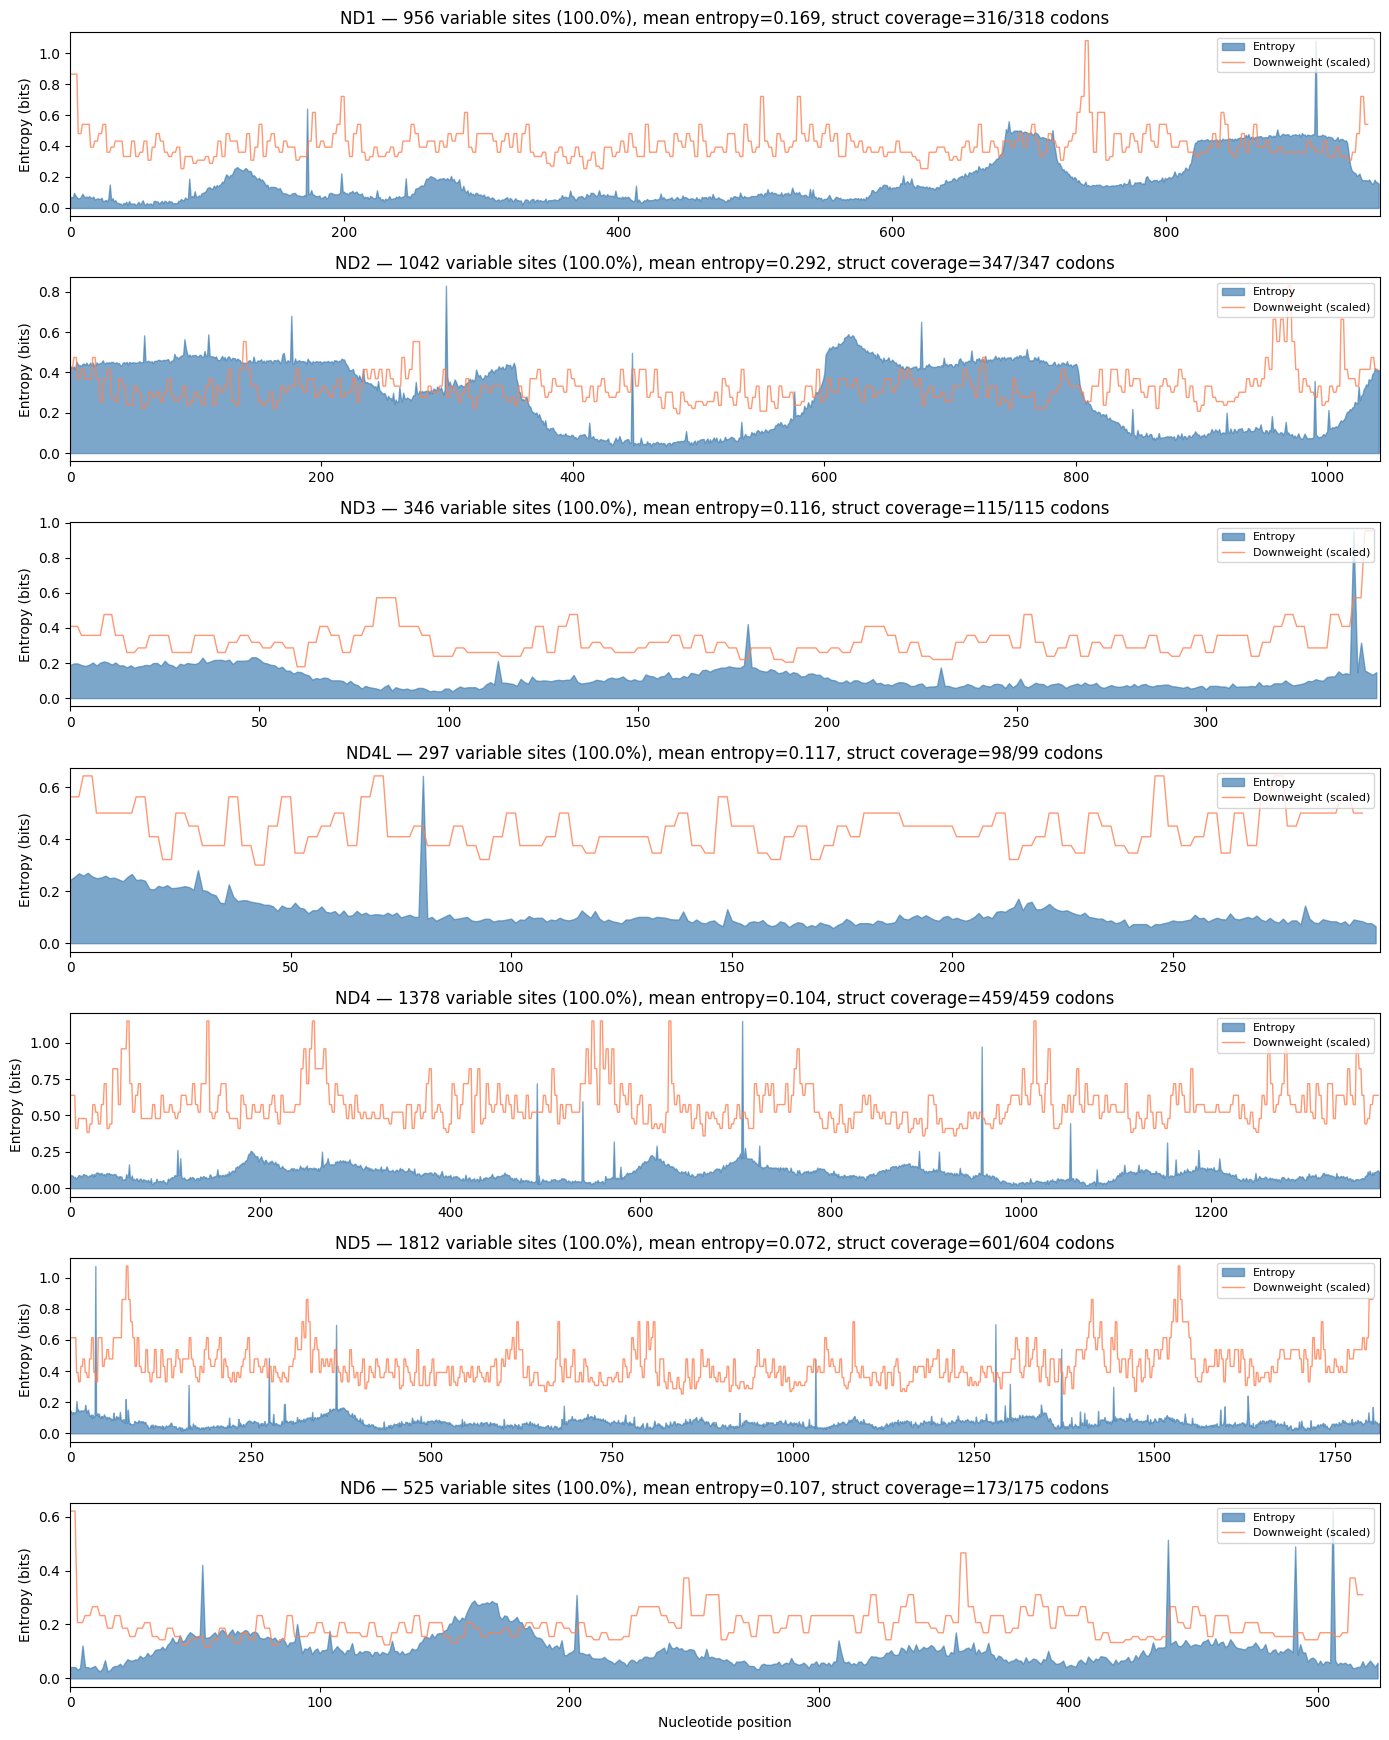

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(nd_genes), 1, figsize=(14, 2.5 * len(nd_genes)))

for ax, gene in zip(axes, sorted(nd_genes.keys(), key=lambda x: nd_genes[x]["start"])):
    stats = gene_variability[gene]
    entropy = stats["per_position_entropy"]
    length = stats["length"]
    n_codons = length // 3
    
    # Expand downweights to nucleotide level for comparison
    dw = mito_contact_summary[gene]["downweight"]
    struct_len = len(dw)
    
    # Create nucleotide-level downweight (repeat each residue weight 3x)
    dw_expanded = np.repeat(dw, 3)[:n_codons * 3]
    
    # Plot entropy
    positions = np.arange(length)
    ax.fill_between(positions, entropy, alpha=0.7, label="Entropy", color="steelblue")
    
    # Overlay downweight (scaled to entropy range for visibility)
    if len(dw_expanded) > 0:
        dw_positions = np.arange(len(dw_expanded))
        dw_scaled = dw_expanded * (entropy.max() / dw_expanded.max()) if dw_expanded.max() > 0 else dw_expanded
        ax.plot(dw_positions, dw_scaled, color="coral", alpha=0.8, lw=1, label="Downweight (scaled)")
    
    ax.set_xlim(0, length)
    ax.set_ylabel("Entropy (bits)")
    ax.set_title(f"{gene} — {stats['n_variable_sites']} variable sites ({stats['pct_variable']:.1f}%), "
                 f"mean entropy={stats['mean_entropy']:.3f}, struct coverage={struct_len}/{n_codons} codons")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Nucleotide position")
plt.tight_layout()
plt.show()

In [11]:
# Verify character composition in extracted ND genes (using processed data from above)
from collections import Counter

total_counts = Counter()
per_gene_counts = {}

for gene, gene_seqs in amtdb_nd_seqs.items():
    gene_counts = Counter()
    for seq in gene_seqs.values():
        gene_counts.update(seq)
    per_gene_counts[gene] = gene_counts
    total_counts.update(gene_counts)

n_samples = len(amtdb_nd_seqs[list(nd_genes.keys())[0]])
total_bases = sum(total_counts.values())
print(f"Total genes: {len(amtdb_nd_seqs)}")
print(f"Total samples per gene: {n_samples}")
print(f"Total bases (extracted ND genes): {total_bases:,}")

print(f"\n{'='*50}")
print("NUCLEOTIDE COMPOSITION (extracted ND genes)")
print(f"{'='*50}")

# Standard nucleotides
standard = ['A', 'C', 'G', 'T']
for nuc in standard:
    count = total_counts[nuc]
    pct = 100 * count / total_bases
    print(f"{nuc}: {count:>12,} ({pct:>6.2f}%)")

# Non-standard characters
non_standard = {k: v for k, v in total_counts.items() if k not in standard}
if non_standard:
    print(f"\n{'='*50}")
    print("NON-STANDARD CHARACTERS")
    print(f"{'='*50}")
    for char, count in sorted(non_standard.items(), key=lambda x: -x[1]):
        pct = 100 * count / total_bases
        print(f"{repr(char)}: {count:>12,} ({pct:>6.3f}%)")
else:
    print(f"\n{'='*50}")
    print("NO NON-STANDARD CHARACTERS (only A, C, G, T)")
    print(f"{'='*50}")

# Per-gene breakdown
print(f"\n{'='*50}")
print("PER-GENE N CONTENT")
print(f"{'='*50}")
print(f"{'Gene':<6} {'Total bases':>12} {'N count':>10} {'N %':>8}")
print("-" * 40)
for gene in sorted(nd_genes.keys(), key=lambda x: nd_genes[x]["start"]):
    counts = per_gene_counts[gene]
    gene_total = sum(counts.values())
    n_count = counts.get('N', 0)
    n_pct = 100 * n_count / gene_total if gene_total > 0 else 0
    print(f"{gene:<6} {gene_total:>12,} {n_count:>10,} {n_pct:>7.2f}%")

Total genes: 7
Total samples per gene: 1940
Total bases (extracted ND genes): 12,330,640

NUCLEOTIDE COMPOSITION (extracted ND genes)
A:    3,522,713 ( 28.57%)
C:    3,838,811 ( 31.13%)
G:    1,526,074 ( 12.38%)
T:    3,198,364 ( 25.94%)

NON-STANDARD CHARACTERS
'N':      244,678 ( 1.984%)

PER-GENE N CONTENT
Gene    Total bases    N count      N %
----------------------------------------
ND1       1,854,640     49,741    2.68%
ND2       2,021,480    109,470    5.42%
ND3         671,240      9,276    1.38%
ND4L        576,180      8,060    1.40%
ND4       2,673,320     31,457    1.18%
ND5       3,515,280     23,976    0.68%
ND6       1,018,500     12,698    1.25%


In [12]:
# Diagnostic: Check ND6 sequence identity separately for coord vs BLAST extracted samples
# This will help identify if the issue is with one extraction method

def compute_identity(seq1, seq2):
    """Compute percent identity between two sequences."""
    if len(seq1) != len(seq2):
        return 0.0
    matches = sum(a == b for a, b in zip(seq1, seq2))
    return 100 * matches / len(seq1)

# Get the set of coordinate-extracted sample IDs (from ref-length samples)
coord_sample_ids = set(amtdb_ref_length.keys())

# Check ND6 identity for both groups
nd6_ref = nd_ref_seqs["ND6"]
nd6_seqs = amtdb_nd_seqs["ND6"]

coord_identities = []
blast_identities = []

for sid, seq in nd6_seqs.items():
    identity = compute_identity(seq, nd6_ref)
    if sid in coord_sample_ids:
        coord_identities.append(identity)
    else:
        blast_identities.append(identity)

print("ND6 Identity vs Reference:")
print(f"\nCoordinate-extracted (n={len(coord_identities)}):")
print(f"  Mean: {np.mean(coord_identities):.1f}%")
print(f"  Min:  {np.min(coord_identities):.1f}%")
print(f"  Max:  {np.max(coord_identities):.1f}%")

print(f"\nBLAST-extracted (n={len(blast_identities)}):")
print(f"  Mean: {np.mean(blast_identities):.1f}%")
print(f"  Min:  {np.min(blast_identities):.1f}%")
print(f"  Max:  {np.max(blast_identities):.1f}%")

# Also check distribution of identities
print(f"\nIdentity distribution:")
bins = [0, 50, 70, 80, 90, 95, 98, 100]
print(f"  {'Range':<12} {'Coord':>8} {'BLAST':>8}")
print(f"  {'-'*30}")
for i in range(len(bins)-1):
    lo, hi = bins[i], bins[i+1]
    n_coord = sum(1 for x in coord_identities if lo <= x < hi)
    n_blast = sum(1 for x in blast_identities if lo <= x < hi)
    print(f"  {lo:>3}-{hi:<3}%     {n_coord:>8} {n_blast:>8}")

ND6 Identity vs Reference:

Coordinate-extracted (n=1374):
  Mean: 98.1%
  Min:  13.1%
  Max:  100.0%

BLAST-extracted (n=566):
  Mean: 99.9%
  Min:  97.7%
  Max:  100.0%

Identity distribution:
  Range           Coord    BLAST
  ------------------------------
    0-50 %           10        0
   50-70 %           21        0
   70-80 %           12        0
   80-90 %           22        0
   90-95 %           39        0
   95-98 %           40        1
   98-100%          589      259


In [20]:
# Save extracted sequences to disk
import pickle

# Save the extracted ND gene sequences (filtered to complete samples)
output_path = Path("data/amtdb_nd_seqs.pkl")
with open(output_path, 'wb') as f:
    pickle.dump(amtdb_nd_seqs, f)
print(f"Saved amtdb_nd_seqs to {output_path}")

# Save reference sequences
ref_output_path = Path("data/nd_ref_seqs.pkl")
with open(ref_output_path, 'wb') as f:
    pickle.dump(nd_ref_seqs, f)
print(f"Saved nd_ref_seqs to {ref_output_path}")

# Save gene metadata
genes_output_path = Path("data/nd_genes.pkl")
with open(genes_output_path, 'wb') as f:
    pickle.dump(nd_genes, f)
print(f"Saved nd_genes to {genes_output_path}")

# Summary of saved data
print(f"\n{'='*50}")
print("SAVED DATA SUMMARY")
print(f"{'='*50}")
print(f"Samples: {len(amtdb_nd_seqs[list(nd_genes.keys())[0]])}")
print(f"Genes: {list(nd_genes.keys())}")
print(f"\nFile sizes:")
for p in [output_path, ref_output_path, genes_output_path]:
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name}: {size_kb:.1f} KB")

Saved amtdb_nd_seqs to data/amtdb_nd_seqs.pkl
Saved nd_ref_seqs to data/nd_ref_seqs.pkl
Saved nd_genes to data/nd_genes.pkl

SAVED DATA SUMMARY
Samples: 1940
Genes: ['ND1', 'ND2', 'ND3', 'ND4L', 'ND4', 'ND5', 'ND6']

File sizes:
  amtdb_nd_seqs.pkl: 12193.6 KB
  nd_ref_seqs.pkl: 6.3 KB
  nd_genes.pkl: 0.9 KB
